# Semantic Segmentation Demonstration In Python


## **Background**

In the previous unit, we used object detection (YOLO) to identify and locate cars using bounding boxes. However, object detection cannot capture precise shapes or identify empty spaces between objects. Semantic segmentation overcomes this by classifying each pixel in an image, enabling a more detailed understanding of the scene.

Semantic segmentation is a computer vision technique that classifies each pixel of an image into a specific category (e.g., road, vehicle, background). Unlike image classification, it provides fine-grained understanding of scenes, making it useful in applications like autonomous driving and surveillance.

## **Objective**

To leverage a pretrained semantic segmentation model (FCN-ResNet50) to perform pixel-level classification of images, enabling precise identification of objects (e.g., cars) as well as surrounding regions such as empty parking spaces.

### Import Libraries


In [2]:
import torch
import torchvision.transforms as T
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps
from IPython.display import display

### Load Model Function


In [3]:
def load_model():
    """
    Loads pretrained FCN-ResNet50 model.
    - Pretrained on COCO dataset
    - Performs semantic segmentation
    """
    model = models.segmentation.fcn_resnet50(weights="DEFAULT")
    model.eval()  # Set to inference mode
    return model


### Preprocess Image

In [4]:
def preprocess_image(image):
    """
    Converts image into tensor format suitable for model
    Steps:
    - Resize
    - Convert to tensor
    - Normalize (IMPORTANT for pretrained models)
    """
    preprocess = T.Compose([
        T.Resize(520),   # Resize shorter side to 520
        T.ToTensor(),    # Convert image to tensor
        T.Normalize(
            mean=[0.485, 0.456, 0.406],   # ImageNet mean
            std=[0.229, 0.224, 0.225]     # ImageNet std
        )
    ])

    return preprocess(image).unsqueeze(0)  # Add batch dimension


### Segmentation Function

In [5]:
def segment_image(model, image):
    """
    Runs inference on the image and returns pixel-wise class predictions
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    input_tensor = preprocess_image(image).to(device)

    with torch.no_grad():  # No gradient needed (faster)
        output = model(input_tensor)["out"][0]

    # Convert probabilities to class labels
    predictions = output.argmax(0).cpu().numpy()

    return predictions


### Decode Segmentation Map

In [6]:

def decode_segmap(predictions):
    """
    Converts class labels into RGB image
    Each class gets a unique color
    """

    # 21 classes (PASCAL VOC style)
    label_colors = np.array([
        (0, 0, 0),        # background
        (128, 0, 0), (0, 128, 0), (128, 128, 0),
        (0, 0, 128), (128, 0, 128), (0, 128, 128),
        (128, 128, 128), (64, 0, 0), (192, 0, 0),
        (64, 128, 0), (192, 128, 0), (64, 0, 128),
        (192, 0, 128), (64, 128, 128), (192, 128, 128),
        (0, 64, 0), (128, 64, 0), (0, 192, 0),
        (128, 192, 0), (0, 64, 128)
    ])

    h, w = predictions.shape
    color_image = np.zeros((h, w, 3), dtype=np.uint8)

    # Assign color to each pixel based on class
    for label in range(len(label_colors)):
        color_image[predictions == label] = label_colors[label]

    return color_image

### Visualisation Function

In [7]:
def visualize(original, seg_image):
    """
    Displays original image and segmented output side-by-side
    """
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(seg_image)
    plt.title("Segmentation Output")
    plt.axis("off")

    plt.show()

### Run

Image size: (2142, 2856)
Image mode: RGB


Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /Users/niltonconstantino/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth
100%|██████████| 135M/135M [02:11<00:00, 1.08MB/s] 


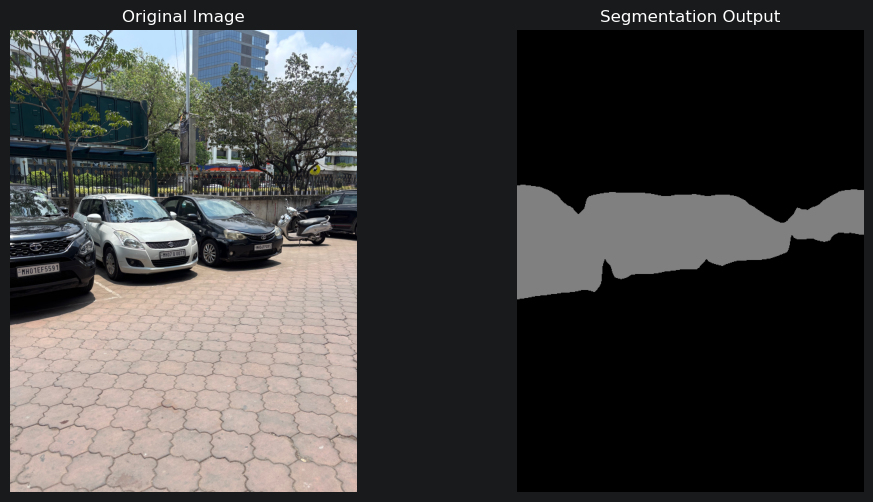

In [8]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    image = ImageOps.exif_transpose(image)  # Fix phone camera rotation
    return image

def run_pipeline():

    image = load_image(image_path)

    print("Image size:", image.size)
    print("Image mode:", image.mode)

    model = load_model()
    predictions = segment_image(model, image)
    segmented_image = decode_segmap(predictions)
    visualize(image, segmented_image)

# Upload and run
image_path = "Vehicle Image.jpg"

image = load_image(image_path)
#display(image)  # Show uploaded image

run_pipeline()
